# Product Category Analysis

Ranks the 50 product categories by volume, profit, and margin, then separately looks at how discounting varies across them.

Builds on [`0_data_overview.ipynb`](0_data_overview.ipynb). See §0.5 below for why Oct 2017 onward is excluded from the category totals here, consistent with `0.1_company_growth.ipynb` §2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE, AQUA = CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2]
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=True, y_grid=False):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def rank_panel(top, bottom, value_col, value_fmt, title_top, title_bottom, xlabel, figsize=(11, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, data, title in [(axes[0], top, title_top), (axes[1], bottom, title_bottom)]:
        data = data.iloc[::-1]
        bars = ax.barh(data['Category Name'], data[value_col], color=BLUE, zorder=3, height=0.65)
        ax.set_title(title, loc='left', color=INK, fontsize=10.5)
        ax.set_xlabel(xlabel)
        style_axis(ax)
        ax.tick_params(axis='y', labelsize=8.5)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: value_fmt(v)))
        xmax = data[value_col].max()
        for bar, v in zip(bars, data[value_col]):
            ax.text(bar.get_width() + xmax * 0.015, bar.get_y() + bar.get_height() / 2,
                     value_fmt(v), va='center', fontsize=8, color=INK_SECONDARY)
        ax.set_xlim(right=xmax * 1.22 if xmax > 0 else 1)
    plt.tight_layout()
    plt.show()

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
print(f"transactions: {df.shape[0]:,} rows, {df['Category Name'].nunique()} categories")

transactions: 180,519 rows, 50 categories


## 0.5 Data-generation artifact: excluding Oct 2017+

Per `0.1_company_growth.ipynb` §2, every order from Oct 2017 onward collapses to exactly 1 line item and per-line Sales/profit run higher than the Jan 2015–Sep 2017 norm (a different regime, not more demand). Category totals below are computed after dropping that window, so a category isn't ranked higher or lower just because more of its (differently-shaped) tail-end orders happened to survive in the raw file.

In [3]:
print(f"rows before exclusion: {len(df):,}")
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df = df[df['order date (DateOrders)'] < '2017-10-01'].copy()
print(f"rows after excluding Oct 2017+: {len(df):,}")

rows before exclusion: 180,519
rows after excluding Oct 2017+: 171,962


`Sales` in this dataset is `Order Item Product Price × Quantity` — the **pre-discount list price**, not what the
customer actually paid. `Order Item Total` (`Sales - Order Item Discount`) is the actual post-discount revenue, and it's
what DataCo's own `Order Item Profit Ratio` field is computed against (verified: `profit / Order Item Total` matches
`Order Item Profit Ratio` to within rounding for 96% of rows, vs. 18% for `profit / Sales`). So margin below uses
`Order Item Total` as the denominator — `profit / revenue actually received`, not `profit / pre-discount list price`,
which would understate margin and skew it further for heavily-discounted categories.

In [4]:
cat_perf = df.groupby('Category Name').agg(
    units=('Order Item Quantity', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    revenue=('Order Item Total', 'sum'),
    avg_discount=('Order Item Discount Rate', 'mean'),
    order_lines=('Order Item Id', 'size'),
).reset_index()
cat_perf['margin_pct'] = cat_perf['profit'] / cat_perf['revenue'] * 100
cat_perf['avg_discount_pct'] = cat_perf['avg_discount'] * 100
cat_perf['profit_k'] = cat_perf['profit'] / 1e3

print(f"{len(cat_perf)} categories, {cat_perf['order_lines'].sum():,} order lines total")
cat_perf[['Category Name', 'units', 'profit', 'margin_pct', 'avg_discount_pct']].describe()

32 categories, 171,962 order lines total


,units,profit,margin_pct,avg_discount_pct
count,32.00000,32.000000,32.000000,32.000000
mean,11727.71875,115187.032320,11.761254,10.197608
std,19827.14091,193695.128556,4.063325,0.298642
min,59.00000,-504.699992,-2.956578,9.344262
25%,799.25000,5028.977495,11.568302,10.149267
50%,1748.00000,9270.509947,12.297344,10.169657
75%,14164.25000,175064.850281,12.840457,10.264752
max,73614.00000,754713.197186,19.248303,10.941177


## 1. Volume — units sold

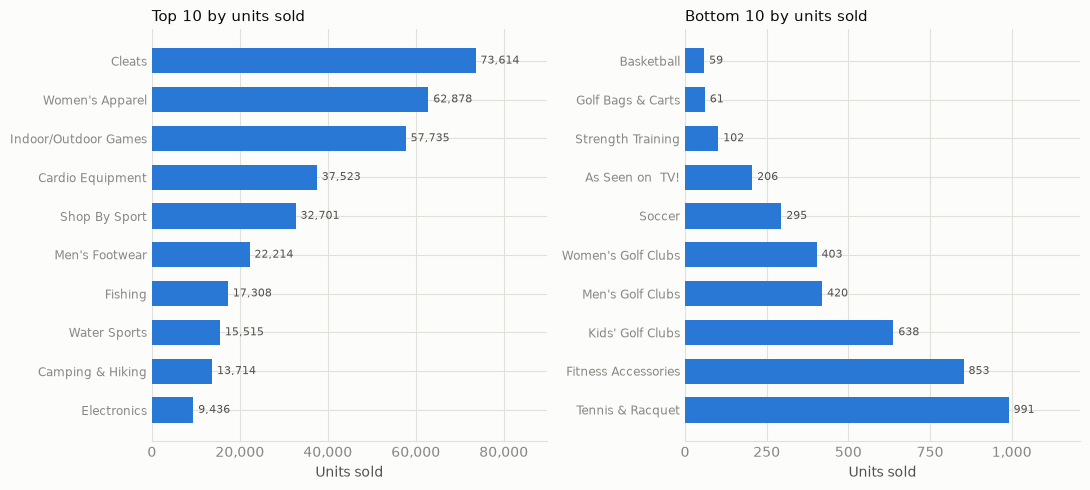

In [5]:
N = 10
top_units = cat_perf.nlargest(N, 'units')
bottom_units = cat_perf.nsmallest(N, 'units')

rank_panel(top_units, bottom_units, 'units', lambda v: f'{v:,.0f}',
           f'Top {N} by units sold', f'Bottom {N} by units sold', 'Units sold')

## 2. Profit — total profit dollars

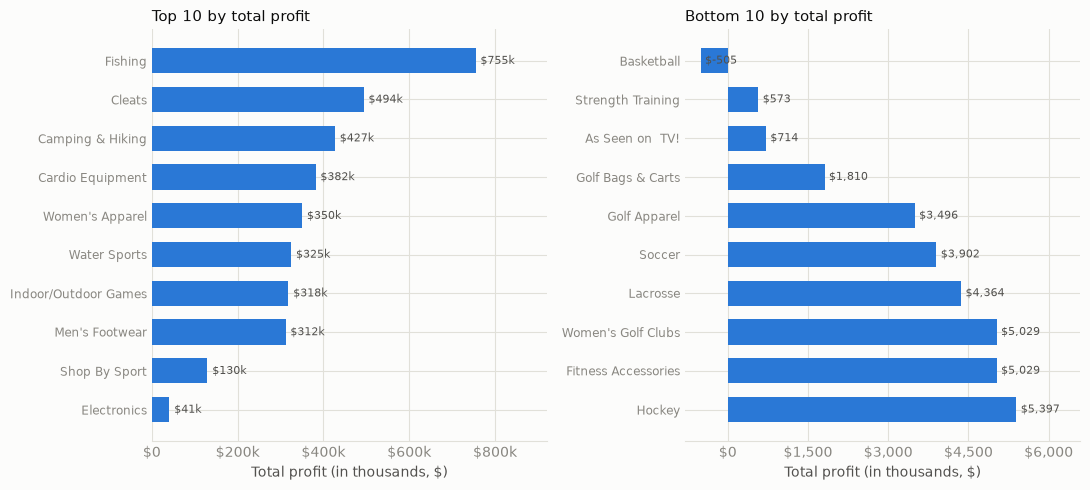

All 50 categories are profitable in aggregate (no negative-profit categories) —
this matches the order-level finding in the interview-mock EDA that DataCo has no true
negative-profit orders, only a heavy-discount cluster. So "worst by profit" here means
lowest profit dollars, not loss-making.


In [6]:
top_profit = cat_perf.nlargest(N, 'profit')
bottom_profit = cat_perf.nsmallest(N, 'profit')

def profit_fmt(v):
    return f'${v:,.0f}k' if v >= 10 else f'${v * 1000:,.0f}'

rank_panel(top_profit, bottom_profit, 'profit_k', profit_fmt,
           f'Top {N} by total profit', f'Bottom {N} by total profit', 'Total profit (in thousands, $)')

print('All 50 categories are profitable in aggregate (no negative-profit categories) —')
print('this matches the order-level finding in the interview-mock EDA that DataCo has no true')
print('negative-profit orders, only a heavy-discount cluster. So "worst by profit" here means')
print('lowest profit dollars, not loss-making.')

## 3. Margin — profit as a % of revenue actually received

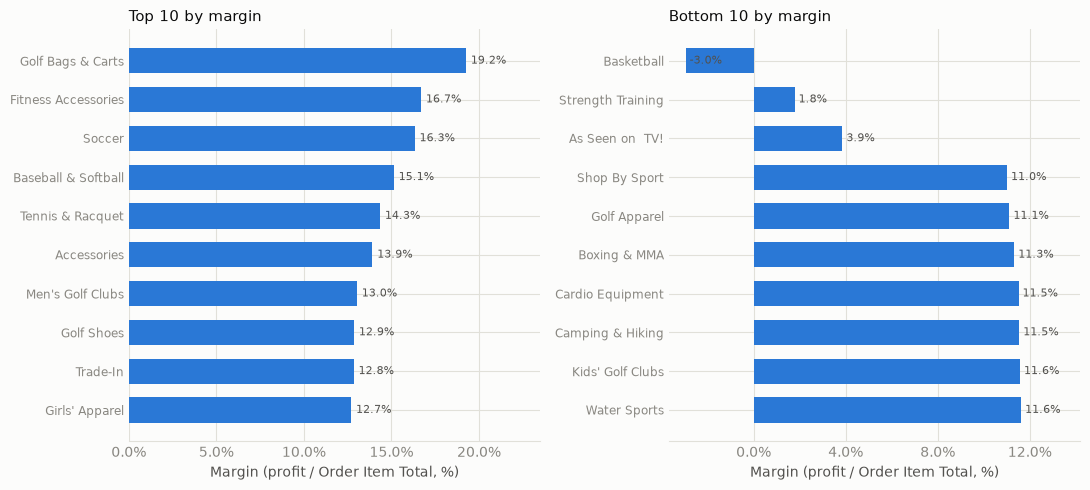

Margin spread across categories: -3.0% - 19.2%


In [7]:
top_margin = cat_perf.nlargest(N, 'margin_pct')
bottom_margin = cat_perf.nsmallest(N, 'margin_pct')

rank_panel(top_margin, bottom_margin, 'margin_pct', lambda v: f'{v:.1f}%',
           f'Top {N} by margin', f'Bottom {N} by margin', 'Margin (profit / Order Item Total, %)')

print(f"Margin spread across categories: {cat_perf['margin_pct'].min():.1f}% - {cat_perf['margin_pct'].max():.1f}%")

## 4. Discount — most vs. least discounted categories

Average `Order Item Discount Rate` per category, not total discount dollars, so this reads as discounting *intensity* rather than discount spend (which just tracks volume).

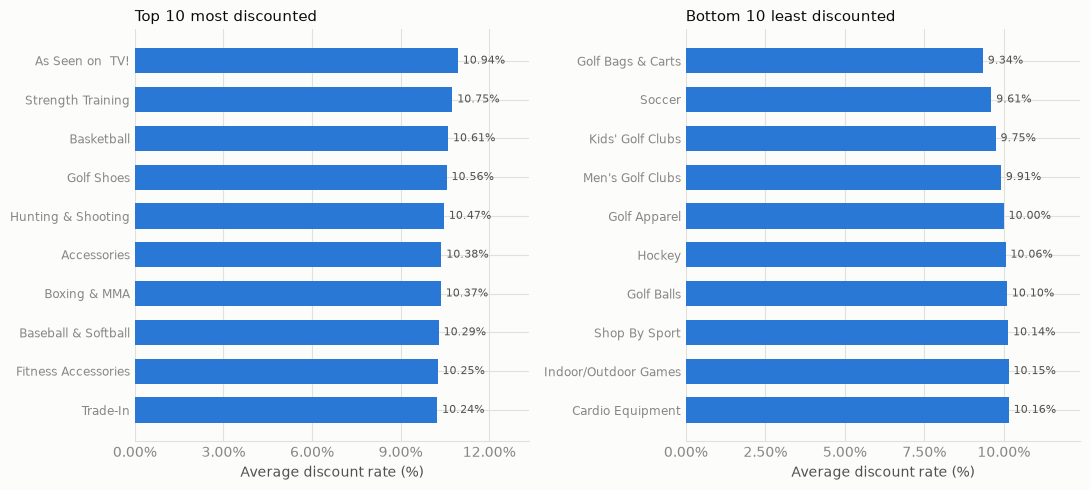

Category averages range 9.34% - 10.94%
(overall mean 10.20%, spread of only 1.60 points across all 50 categories)
Order-line-level discount rate std: 7.04 points — 
category averages are within noise of that random spread, consistent with discount being
assigned independent of category rather than as a category-level pricing lever.


In [8]:
top_discount = cat_perf.nlargest(N, 'avg_discount_pct')
bottom_discount = cat_perf.nsmallest(N, 'avg_discount_pct')

rank_panel(top_discount, bottom_discount, 'avg_discount_pct', lambda v: f'{v:.2f}%',
           f'Top {N} most discounted', f'Bottom {N} least discounted', 'Average discount rate (%)')

overall_avg = cat_perf['avg_discount'].mean() * 100
spread = cat_perf['avg_discount_pct'].max() - cat_perf['avg_discount_pct'].min()
print(f"Category averages range {cat_perf['avg_discount_pct'].min():.2f}% - {cat_perf['avg_discount_pct'].max():.2f}%")
print(f"(overall mean {overall_avg:.2f}%, spread of only {spread:.2f} points across all 50 categories)")
print(f"Order-line-level discount rate std: {df['Order Item Discount Rate'].std()*100:.2f} points — ")
print("category averages are within noise of that random spread, consistent with discount being")
print("assigned independent of category rather than as a category-level pricing lever.")

## 5. Profit vs. volume, sized by margin

All 50 categories at once: x = total profit, y = units sold, bubble size = margin %.

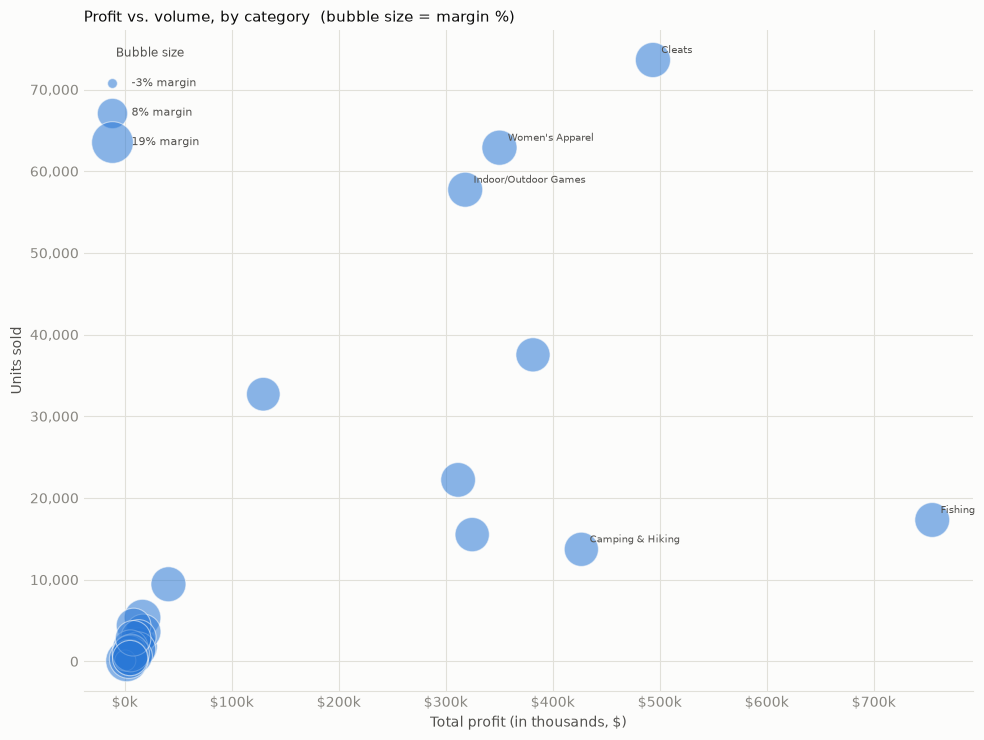

In [9]:
fig, ax = plt.subplots(figsize=(10, 7.5))

size_min, size_max = 50, 900
m_min, m_max = cat_perf['margin_pct'].min(), cat_perf['margin_pct'].max()
sizes = np.interp(cat_perf['margin_pct'], (m_min, m_max), (size_min, size_max))

ax.scatter(cat_perf['profit_k'], cat_perf['units'], s=sizes, color=BLUE, alpha=0.55,
           edgecolor=SURFACE, linewidth=0.8, zorder=3)
ax.set_xlabel('Total profit (in thousands, $)')
ax.set_ylabel('Units sold')
ax.set_title('Profit vs. volume, by category  (bubble size = margin %)', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True, y_grid=True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

to_label = pd.concat([
    cat_perf.nlargest(3, 'profit'),
    cat_perf.nlargest(3, 'units'),
]).drop_duplicates('Category Name')
for _, row in to_label.iterrows():
    ax.annotate(row['Category Name'][:22], (row['profit_k'], row['units']), textcoords='offset points',
                xytext=(6, 5), fontsize=7.5, color=INK_SECONDARY)

legend_margins = [m_min, (m_min + m_max) / 2, m_max]
legend_sizes = np.interp(legend_margins, (m_min, m_max), (size_min, size_max))
handles = [ax.scatter([], [], s=s, color=BLUE, alpha=0.55, edgecolor=SURFACE, linewidth=0.8) for s in legend_sizes]
labels = [f'{m:.0f}% margin' for m in legend_margins]
legend = ax.legend(handles, labels, title='Bubble size', loc='upper left', frameon=False,
                    labelspacing=1.6, borderpad=1, fontsize=8, title_fontsize=8.5)
plt.setp(legend.get_title(), color=INK_SECONDARY)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

plt.tight_layout()
plt.show()

## Takeaways

- **Volume vs. profit vs. margin don't rank the same categories.** Cross-check the top-10 lists above — a category that's a volume leader (e.g. Cleats, Women's Apparel) isn't necessarily a profit or margin leader, and vice versa. Any pricing/assortment decision should specify *which* of the three it's optimizing for.
- **"Worst" here is relative, not a loss.** Every category is profitable in aggregate — the bottom-10 lists are the lowest performers among 50 profitable categories, not underwater ones. This is consistent with [[orders-csv-eda-notebook]]'s Q7 finding of no true negative-profit orders.
- **Margin uses `Order Item Total` (post-discount revenue), not `Sales` (pre-discount list price), as the denominator** — matched against DataCo's own `Order Item Profit Ratio` field to confirm. Using list price instead would understate every category's margin and more so for heavily-discounted ones, which can flip rankings, not just rescale them.
- **Discounting doesn't vary meaningfully by category.** Average discount rate across categories spans roughly one percentage point (~9.3%-10.9%) around a ~10% mean, and that spread is within what you'd expect from random order-line-level noise alone. In other words, discounting in this dataset looks like it's applied independent of category rather than as a deliberate category-level lever — so a "most discounted category" framing shouldn't be read as evidence of a merchandising strategy.
- **The bubble chart makes the volume/profit/margin mismatch visible in one view**: the biggest bubbles (highest margin) aren't concentrated at the high-profit or high-volume end — small, high-margin categories and large, thin-margin categories both exist, so no single axis identifies the "best" category on its own.